Importing Libraries 

In [3]:
import pandas as pd 
import numpy 
import matplotlib.pyplot as plt
import bokeh as bk
import requests
import time
print("imports done")

imports done


Helper Function to fetch data

In [7]:
BASE_URL = "https://api.jolpi.ca/ergast/f1"
print("Works ergast")
def fetch_ergast(endpoint, params=None):
    url = f"{BASE_URL}/{endpoint}.json"
    response = requests.get(url, params=params)

    if response.status_code == 429:
        print(" Rate limit hit, backing off...")
        time.sleep(2.0)
        response = requests.get(url, params=params)

    response.raise_for_status()
    time.sleep(0.2)
    return response.json()

Works ergast


Fetching all races between 2011 and 2025 (because the rules don't differ a great deal, as compared to races in 90's to 2020's)


In [20]:
race_data=[]
for season in range(2011,2026,1):
    racetable=fetch_ergast(f"{season}/races")
    races=racetable["MRData"]["RaceTable"]["Races"]
    # print(f"{season} drivers fetched")
    for d in races:
     race_data.append({
        "season": d["season"],
        "raceId": d["round"],
        "raceName":d["raceName"],
        "date":d["date"],
        "time":d["time"],
        "circuitId":d["Circuit"]["circuitId"]
    })

df_races=pd.DataFrame(race_data)
df_races.head()
df_races.shape

(310, 6)

In [21]:
# Cleaning up the race data table
# df_races["round"]=df_races.rename(columns={"round":"raceId"},inplace=True)
# df_races.drop(["url","FirstPractice","SecondPractice","ThirdPractice","Qualifying","Sprint","SprintQualifying","SprintShootout","round"],axis=1,inplace=True)
df_races.head()

,season,raceId,raceName,date,time,circuitId
0,2011,1,Australian Grand Prix,2011-03-27,06:00:00Z,albert_park
1,2011,2,Malaysian Grand Prix,2011-04-10,08:00:00Z,sepang
2,2011,3,Chinese Grand Prix,2011-04-17,07:00:00Z,shanghai
3,2011,4,Turkish Grand Prix,2011-05-08,12:00:00Z,istanbul
4,2011,5,Spanish Grand Prix,2011-05-22,12:00:00Z,catalunya


In [22]:
# Date time format conversion 
df_races["time"]=(pd.to_datetime(df_races["time"], format="%H:%M:%SZ").dt.time)
df_races["date"] = pd.to_datetime(df_races["date"]).dt.strftime("%d-%m-%Y")
df_races.head(310)

,season,raceId,raceName,date,time,circuitId
0,2011,1,Australian Grand Prix,27-03-2011,06:00:00,albert_park
1,2011,2,Malaysian Grand Prix,10-04-2011,08:00:00,sepang
2,2011,3,Chinese Grand Prix,17-04-2011,07:00:00,shanghai
3,2011,4,Turkish Grand Prix,08-05-2011,12:00:00,istanbul
4,2011,5,Spanish Grand Prix,22-05-2011,12:00:00,catalunya
...,...,...,...,...,...,...
305,2025,20,Mexico City Grand Prix,26-10-2025,20:00:00,rodriguez
306,2025,21,São Paulo Grand Prix,09-11-2025,17:00:00,interlagos
307,2025,22,Las Vegas Grand Prix,23-11-2025,04:00:00,vegas
308,2025,23,Qatar Grand Prix,30-11-2025,16:00:00,losail


In [23]:
df_races.to_csv(f"data/raw/races.csv",index=False)

Now Fetching the results Table


In [ ]:
# Results for all the races is fetched 
results = []

for season in range(2011, 2026):
    offset = 0
    limit = 100

    while True:
        res_json = fetch_ergast(
            f"{season}/results",
            params={"limit": limit, "offset": offset}
        )

        races = res_json["MRData"]["RaceTable"]["Races"]
        if not races:
            break  
        for race in races:
            race_id = race["round"]   

            for r in race["Results"]:
                results.append({
                    "season": season,
                    "round": int(race_id),
                    "driverId": r["Driver"]["driverId"],
                    "constructorId": r["Constructor"]["constructorId"],
                    "position": int(r["position"]),
                    "status": r["status"],
                    "grid": r["grid"],
                    "laps":r["laps"]
                })

        offset += limit
df_results=pd.DataFrame(results)


 Rate limit hit, backing off...
 Rate limit hit, backing off...
 Rate limit hit, backing off...
 Rate limit hit, backing off...
 Rate limit hit, backing off...
 Rate limit hit, backing off...
 Rate limit hit, backing off...


In [90]:
df_results["round"]=df_results.rename(columns={"round":"raceId"},inplace=True)
df_results.shape
df_results.head(6455)

,season,raceId,driverId,constructorId,position,status,grid,laps,round
0,2011,1,vettel,red_bull,1,Finished,1,58,None
1,2011,1,hamilton,mclaren,2,Finished,2,58,None
2,2011,1,petrov,renault,3,Finished,6,58,None
3,2011,1,alonso,ferrari,4,Finished,5,58,None
4,2011,1,webber,red_bull,5,Finished,3,58,None
...,...,...,...,...,...,...,...,...,...
6450,2025,24,albon,williams,16,Finished,17,58,None
6451,2025,24,hadjar,rb,17,Lapped,9,57,None
6452,2025,24,lawson,rb,18,Lapped,13,57,None
6453,2025,24,gasly,alpine,19,Lapped,19,57,None


In [59]:
df_results.drop(["round"],axis=1,inplace=True)
# df_results["statusId"]=df_results["statusId"].astype(int)
df_results.head()


,season,raceId,driverId,constructorId,position,statusId
0,2011,1,vettel,red_bull,1,Finished
1,2011,1,hamilton,mclaren,2,Finished
2,2011,1,petrov,renault,3,Finished
3,2011,1,alonso,ferrari,4,Finished
4,2011,1,webber,red_bull,5,Finished


In [91]:
df_results.to_csv(f"data/raw/race_results.csv")

Fetching Driver Details 

In [99]:
driver_data=[]
for season in range(2011,2026,1):
    driverstable=fetch_ergast(f"{season}/drivers")
    drivers=driverstable["MRData"]["DriverTable"]["Drivers"]
    # print(f"{season} drivers fetched")
    for d in drivers:
     driver_data.append({
        "driverId": d["driverId"],
        "firstname": d["givenName"],
        "surname":d["familyName"],
        "nationality":d.get("nationality")
    })

df_drivers=pd.DataFrame(driver_data)
df_drivers.head()
df_drivers.shape

(354, 4)

In [101]:

df_drivers=df_drivers.drop_duplicates(subset=["driverId"]).reset_index(drop=True)
df_drivers.head()
df_drivers.shape

(89, 4)

In [109]:
df_drivers.to_csv(f"data/raw/drivers.csv")

Fetching Constructors details

In [105]:
cons_data=[]
for season in range(2011,2026,1):
    constable=fetch_ergast(f"{season}/constructors")
    cons=constable["MRData"]["ConstructorTable"]["Constructors"]

    for c in cons:
        cons_data.append({
            "constructorId":c["constructorId"],
            "name":c["name"],
            "nationality":c.get("nationality")
        })
    
df_cons=pd.DataFrame(cons_data)
df_cons.head()
df_cons.shape

(157, 3)

In [108]:
df_cons=df_cons.drop_duplicates(subset=["constructorId"]).reset_index(drop=True)
df_cons.head()
df_cons.shape

(23, 3)

In [110]:
df_cons.to_csv("data/raw/constructors.csv")

Fetching pit stops 


In [111]:
import time

pits_data = []

START_SEASON = 2011
END_SEASON = 2025
SLEEP_SECONDS = 0.5  # rate-limit friendly

for season in range(START_SEASON, END_SEASON + 1):

    races_json = fetch_ergast(f"{season}/races")
    races = races_json["MRData"]["RaceTable"]["Races"]

    print(f"Season {season}: {len(races)} races")

    for race in races:
        round_no = int(race["round"])

        pits_json = fetch_ergast(f"{season}/{round_no}/pitstops")
        race_table = pits_json["MRData"]["RaceTable"]["Races"]

        if not race_table:
            continue

        pitstops = race_table[0].get("PitStops", [])

        for pit in pitstops:
            pits_data.append({
                "season": season,
                "raceId": round_no,
                "driverId": pit["driverId"],
                "lap": int(pit["lap"]),
                "stop": int(pit["stop"]),
                "duration": (pit["duration"])
            })

        # prevent 429
        time.sleep(SLEEP_SECONDS)

print(f"Finished fetching pit stops: {len(pits_data)} records")


Season 2011: 19 races
Season 2012: 20 races
Season 2013: 19 races
Season 2014: 19 races
Season 2015: 19 races
Season 2016: 21 races
Season 2017: 20 races
 Rate limit hit, backing off...
 Rate limit hit, backing off...
 Rate limit hit, backing off...
 Rate limit hit, backing off...
Season 2018: 21 races
 Rate limit hit, backing off...
 Rate limit hit, backing off...
 Rate limit hit, backing off...
 Rate limit hit, backing off...
 Rate limit hit, backing off...
 Rate limit hit, backing off...
 Rate limit hit, backing off...
 Rate limit hit, backing off...
 Rate limit hit, backing off...
 Rate limit hit, backing off...
Season 2019: 21 races
 Rate limit hit, backing off...
 Rate limit hit, backing off...
 Rate limit hit, backing off...
 Rate limit hit, backing off...
 Rate limit hit, backing off...
 Rate limit hit, backing off...
 Rate limit hit, backing off...
 Rate limit hit, backing off...
 Rate limit hit, backing off...
 Rate limit hit, backing off...
Season 2020: 17 races
 Rate limit 

In [112]:
df_pits=pd.DataFrame(pits_data)
df_pits.head(8541)

,season,raceId,driverId,lap,stop,duration
0,2011,1,alguersuari,1,1,26.898
1,2011,1,michael_schumacher,1,1,25.021
2,2011,1,webber,11,1,23.426
3,2011,1,alonso,12,1,23.251
4,2011,1,massa,13,1,23.842
...,...,...,...,...,...,...
8536,2025,24,gasly,40,2,22.234
8537,2025,24,colapinto,40,2,22.955
8538,2025,24,piastri,41,1,21.565
8539,2025,24,stroll,42,1,21.535


In [113]:
df_pits.to_csv("data/raw/pits.csv")

Status Fetching

In [114]:
status_data = []

limit = 100
offset = 0

while True:
    status_json = fetch_ergast(
        "status",
        params={"limit": limit, "offset": offset}
    )

    statuses = status_json["MRData"]["StatusTable"]["Status"]

    if not statuses:
        break

    for s in statuses:
        status_data.append({
            "statusId": int(s["statusId"]),
            "status": s["status"]
        })

    offset += limit

print("All statuses fetched")

All statuses fetched


In [115]:
df_status=pd.DataFrame(status_data)
df_status.shape

(136, 2)

In [116]:
df_status.head(136)

,statusId,status
0,1,Finished
1,11,+1 Lap
2,5,Engine
3,12,+2 Laps
4,3,Accident
...,...,...
131,35,Refuelling
132,93,Safety belt
133,136,Seat
134,59,Tyre puncture


In [117]:
df_status.to_csv("data/raw/status.csv")

Creating a pit stop summary per driver per race


In [4]:
df_races=pd.read_csv("data/raw/races.csv")
df_results=pd.read_csv("data/raw/race_results.csv")
df_drivers=pd.read_csv("data/raw/drivers.csv")
df_cons=pd.read_csv("data/raw/constructors.csv")
df_pits=pd.read_csv("data/raw/pits.csv")
df_status=pd.read_csv("data/raw/status.csv")

In [8]:
# pit stop join with season and driver id
pit_aggr=(df_pits.groupby(["season","raceId","driverId"], as_index=False)
          .agg(
              pit_stop_count=("stop","count"),
              total_pit_time=("duration","sum"),
              first_pit_lap=("lap","min"),
              last_pit_lap=("lap","max")
          )
)

In [11]:
def drop_unnamed(df):
    return df.loc[:, ~df.columns.str.contains("^Unnamed")]

df_races = drop_unnamed(df_races)
df_results = drop_unnamed(df_results)
df_drivers = drop_unnamed(df_drivers)
df_cons = drop_unnamed(df_cons)
df_pits = drop_unnamed(df_pits)
df_status = drop_unnamed(df_status)


In [9]:
# # Debug/sanity check
# for name, df in {
#     # "races": df_races,
#     "results": df_results,
#     "status":df_status
#     # "pit_agg": pit_aggr
# }.items():
#     print(name, df["statusId"].dtype)


In [12]:
# base table formation 
df_base=(
    df_results.merge(df_races, on=["season","raceId"], how="left")
         .merge(pit_aggr,on=["season","raceId","driverId"], how="left")
         .merge(df_drivers,on=["driverId"], how ="left")
         .merge(df_cons,on="constructorId", how="left")
         .merge(df_status, on="status", how="left")
         )

In [13]:
df_base.shape
df_base.head()
df_base.to_csv("data/raw/base_table_clean.csv")

In [14]:
# dropping extra indexed rows

df_base = df_base.loc[:, ~df_base.columns.str.startswith("Unnamed")]


In [15]:
df_base = df_base.rename(columns={
    "nationality_x": "driver_nationality",
    "nationality_y": "constructor_nationality",
    "name": "constructor_name"
})


In [16]:
df_base.to_csv("data/raw/base_table_clean.csv", index=False)

In [17]:
df_base.columns
df_base.head()
df_base.info()

<class 'pandas.DataFrame'>
RangeIndex: 6455 entries, 0 to 6454
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   season                   6455 non-null   int64  
 1   raceId                   6455 non-null   int64  
 2   driverId                 6455 non-null   str    
 3   constructorId            6455 non-null   str    
 4   position                 6455 non-null   int64  
 5   status                   6455 non-null   str    
 6   grid                     6455 non-null   int64  
 7   laps                     6455 non-null   int64  
 8   round                    0 non-null      float64
 9   raceName                 6455 non-null   str    
 10  date                     6455 non-null   str    
 11  time                     6455 non-null   str    
 12  circuitId                6455 non-null   str    
 13  pit_stop_count           5996 non-null   float64
 14  total_pit_time           5996 non-n

In [18]:
# checking for duplicates
dupes = df_base.duplicated(subset=["season", "raceId", "driverId"]).sum()
dupes


np.int64(0)

In [19]:
# null check
df_base[["season","raceId","driverId"]].isna().sum()

season      0
raceId      0
driverId    0
dtype: int64

In [20]:
# pit_stop validation

df_base["pit_stop_count"].isna().sum()

np.int64(459)

In [21]:
df_base["pit_stop_count"]=df_base["pit_stop_count"].fillna(0).astype(int)
df_base["total_pit_time"]=df_base["total_pit_time"].fillna(0)

In [22]:
df_base["pit_stop_count"].value_counts().sort_index

<bound method Series.sort_index of pit_stop_count
1    3623
2    2207
0     459
3     160
4       6
Name: count, dtype: int64>

In [23]:
df_base["status"].value_counts().head(10)

status
Finished     3423
+1 Lap       1274
Lapped        297
+2 Laps       283
Retired       205
Collision     190
Accident      105
Engine         77
Gearbox        54
+3 Laps        54
Name: count, dtype: int64

In [24]:
df_base["finished"]=df_base["status"].str.contains("Finished",na=False)

In [25]:
df_results=pd.read_csv("data/raw/race_results.csv")
grid_lookup=df_results[[
    "season","raceId","driverId","grid"
]]
df_base=df_base.merge(grid_lookup,on=["season","raceId","driverId"],how="left")

In [28]:
df_base.rename(columns={"grid_x": "grid"}, inplace=True)


In [29]:
df_base["position_gained"]=df_base["grid"]-df_base["position"]

In [30]:
df_base.drop(["round"],axis=1,inplace=True)

In [31]:
df_base["position_gained"].describe()

count    6455.000000
mean       -0.156468
std         5.468307
min       -24.000000
25%        -2.000000
50%         0.000000
75%         3.000000
max        21.000000
Name: position_gained, dtype: float64

In [34]:
df_base.groupby("pit_stop_count")["position_gained"].mean()


pit_stop_count
0   -6.967320
1    0.576594
2    0.123697
3   -0.900000
4   -5.000000
Name: position_gained, dtype: float64

In [36]:
race_gains = (
    df_base
    .groupby(["season", "raceId"])["position_gained"]
    .median()
    .sort_values(ascending=False)
)

race_gains.head(10)


season  raceId
2012    12        5.0
2017    14        3.5
2012    8         3.0
2011    7         3.0
2016    5         3.0
2013    8         3.0
2018    4         3.0
2022    8         2.5
2015    15        2.5
2012    18        2.5
Name: position_gained, dtype: float64

In [37]:
df_base.groupby("finished")["position_gained"].describe()


,count,mean,std,min,25%,50%,75%,max
finished,,,,,,,,
False,3032.0,-2.055409,6.263137,-24.0,-5.0,-1.0,2.0,16.0
True,3423.0,1.525562,3.953097,-19.0,-1.0,1.0,3.0,21.0


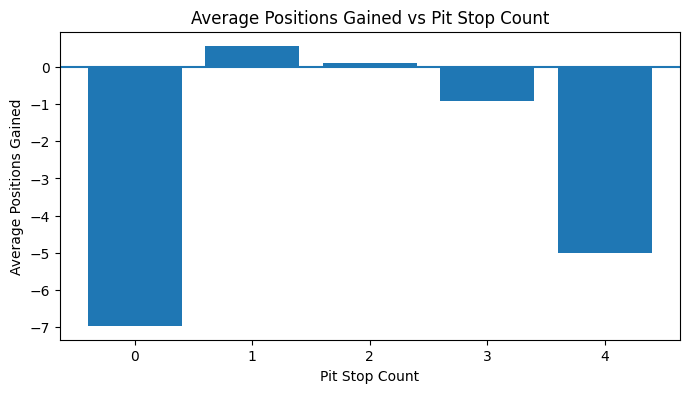

In [38]:
mean_gain = (
    df_base
    .groupby("pit_stop_count")["position_gained"]
    .mean()
)

plt.figure(figsize=(8,4))
plt.bar(mean_gain.index, mean_gain.values)
plt.axhline(0)
plt.xlabel("Pit Stop Count")
plt.ylabel("Average Positions Gained")
plt.title("Average Positions Gained vs Pit Stop Count")
plt.show()

Figure X shows the average number of positions gained as a function of pit stop count. While drivers who avoided pit stops experienced significant position loss, one- and two-stop strategies were not associated with negative outcomes on average. This non-linear relationship suggests that the cost of pitting is frequently offset by race dynamics, motivating further investigation into race-level effects

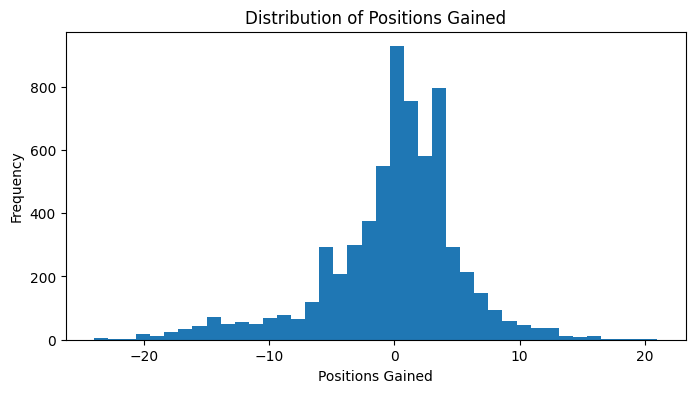

In [126]:
plt.figure(figsize=(8,4))
plt.hist(df_base["position_gained"], bins=40)
plt.xlabel("Positions Gained")
plt.ylabel("Frequency")
plt.title("Distribution of Positions Gained")
plt.show()


In [39]:
race_median = (
    df_base
    .groupby(["season","raceId"])["position_gained"]
    .median()
    .sort_values(ascending=False)
)

race_median.head(10)


season  raceId
2012    12        5.0
2017    14        3.5
2012    8         3.0
2011    7         3.0
2016    5         3.0
2013    8         3.0
2018    4         3.0
2022    8         2.5
2015    15        2.5
2012    18        2.5
Name: position_gained, dtype: float64

In [40]:
df_base.groupby("finished")["position_gained"].mean()


finished
False   -2.055409
True     1.525562
Name: position_gained, dtype: float64

this metric signifies that drivers who finish gain positions not only because the driver infront dnfed but a major chunk of it goes to the strategy

In [41]:
race_stats = (
    df_base
    .groupby(["season","raceId"])
    .agg(
        median_gain=("position_gained","median"),
        mean_gain=("position_gained","mean"),
        std_gain=("position_gained","std"),
        avg_pitstops=("pit_stop_count","mean")
    )
)


In [42]:
interesting=race_stats[(race_stats["median_gain"]>=4)&(race_stats["avg_pitstops"]>=1.5)]

In [43]:
pit_cluster=(
    df_pits.groupby(["season","raceId","lap"])
    .size()
    .reset_index(name="num_pitstops")
)

In [44]:
pit_cluster[pit_cluster["num_pitstops"]>=8]

,season,raceId,lap,num_pitstops
99,2011,7,19,8
109,2011,8,14,8
120,2011,9,11,10
121,2011,9,12,8
149,2011,11,12,10
...,...,...,...,...
4398,2025,12,11,8
4407,2025,13,12,12
4444,2025,15,23,10
4573,2025,23,7,16


In [45]:
df_base[df_base["finished"]].groupby(["season","raceId"])["position_gained"].median().sort_values(ascending=False).head(10)


season  raceId
2021    11        7.0
2012    12        6.0
2017    14        5.0
        8         5.0
2018    4         5.0
2011    7         5.0
2021    20        4.5
2019    11        4.0
2012    18        4.0
        8         4.0
Name: position_gained, dtype: float64

In [140]:
race_stats.sort_values("avg_pitstops", ascending=False).head(10)


median_gain  mean_gain  std_gain  avg_pitstops
season raceId                                                
2014   18              0.5        0.0  3.788528      1.666667
       17              0.0        0.0  4.405878      1.666667
2025   9               0.0        0.0  4.977728      1.578947
2024   3               1.0        0.0  5.916080      1.578947
2021   20              1.0        0.0  5.231484      1.500000
2015   4               0.5        0.0  3.741657      1.500000
       5               1.0        0.0  3.464102      1.500000
       6               0.5       -1.0  4.735087      1.500000
2020   15              0.5        0.0  4.768316      1.500000
       14             -3.5       -1.9  7.972981      1.500000

In [46]:
candidates = (
    race_stats
    .reset_index()
    .merge(
        df_base.groupby(["season","raceId"])["finished"].mean().reset_index(name="finish_rate"),
        on=["season","raceId"]
    )
)

deep_dive_candidates = candidates[
    (candidates["median_gain"] >= 2) &
    # (candidates["avg_pitstops"] >= 1.5)
    (candidates["finish_rate"] >= 0.7)
].sort_values("median_gain", ascending=False)

deep_dive_candidates.head()


,season,raceId,median_gain,mean_gain,std_gain,avg_pitstops,finish_rate
46,2013,8,3.0,0.0,6.775305,1.363636,0.818182
36,2012,18,2.5,0.0,9.491415,1.250000,0.708333
191,2020,13,2.0,0.0,6.920602,1.500000,0.750000


In [47]:
median_cutoff = race_stats["median_gain"].quantile(0.90)
pit_cutoff = race_stats["avg_pitstops"].quantile(0.75)

deep_dive_candidates = candidates[
    (candidates["median_gain"] >= median_cutoff) &
    (candidates["avg_pitstops"] >= pit_cutoff)
].sort_values("median_gain", ascending=False)

deep_dive_candidates.head(10)


,season,raceId,median_gain,mean_gain,std_gain,avg_pitstops,finish_rate
130,2017,14,3.5,0.0,8.534759,1.5,0.55
140,2018,4,3.0,0.0,7.362780,1.5,0.65
121,2017,5,2.0,0.0,7.341303,1.5,0.15
159,2019,2,2.0,0.0,5.140141,1.5,0.55
191,2020,13,2.0,0.0,6.920602,1.5,0.75
86,2015,10,1.5,0.0,6.407233,1.5,0.70
187,2020,9,1.5,0.0,5.712406,1.5,0.60
189,2020,11,1.5,0.0,7.433919,1.5,0.75
266,2024,5,1.5,0.0,3.986820,1.5,0.85


Initial attempts to identify races with extreme median position gains and high completion rates yielded no results, indicating that strongly chaotic and fully classified races rarely coexist. Selection criteria were therefore relaxed to capture races with moderate but systematic position reshuffling, which better reflects real-world race dynamics.

### Selection of Deep-Dive Race

Candidate races were identified based on elevated median position gains and widespread pit stop participation. Among these, the 2013 season, race 8, was selected for detailed analysis due to its combination of significant field reshuffling and a high proportion of classified finishers. This indicates that position gains were not primarily driven by attrition, making it an ideal case to study the interaction between pit strategy and race dynamics.


# Primary Selection: 
 Season:2013, raceId: 8

# Backup Selection
 Season:2017, raceId:14

In [48]:
def lap_time_to_ms(t):
    minutes, rest = t.split(":")
    seconds, millis = rest.split(".")
    return (
        int(minutes) * 60_000 +
        int(seconds) * 1_000 +
        int(millis)
    )


In [ ]:
laps_data=[]

SEASON=2013
ROUND=8 
limit=100
offset=0
while True:
    laps_json=fetch_ergast(f"{SEASON}/{ROUND}/laps", params={"limit":limit,"offset":offset})
    races=laps_json["MRData"]["RaceTable"]["Races"]
    if not races:
        break
    laps=races[0].get("Laps",[])
    if not laps:
        break
    for lap in laps:
        lap_num=int(lap["number"])
        for timing in lap["Timings"]:
            laps_data.append({
                "season":SEASON,
                "raceId":ROUND,
                "lap":lap_num,
                "driverId":timing["driverId"],
                "lap_time_ms":lap_time_to_ms(timing["time"])
            })
    offset+=limit
    time.sleep(0.3)
print(f"Fetched {len(laps_data)} lap-time records")


In [163]:
df_laps=pd.DataFrame(laps_data)
df_laps.head()

,season,raceId,lap,driverId,lap_time_ms
0,2013,8,1,hamilton,102428
1,2013,8,1,vettel,103277
2,2013,8,1,rosberg,104157
3,2013,8,1,sutil,105265
4,2013,8,1,massa,106125


In [51]:
# temporary cell remove from final
df_laps=pd.read_csv("data/raw/laps_2013_8.csv")

In [52]:
df_laps.shape
df_laps["driverId"].nunique()
df_laps["lap"].max()
df_laps.head()

,season,raceId,lap,driverId,lap_time_ms
0,2013,8,1,hamilton,102428
1,2013,8,1,vettel,103277
2,2013,8,1,rosberg,104157
3,2013,8,1,sutil,105265
4,2013,8,1,massa,106125


In [53]:
df_laps.to_csv("data/raw/laps_2013_8.csv", index=False)

Preparing Lap-time metrics now for the fetched laps

In [54]:
lap_variance = (
    df_laps
    .groupby("lap")["lap_time_ms"]
    .std()
    .reset_index(name="lap_std_ms")
)
#  primary safety car proxy

In [55]:
race_pits = df_pits[
    (df_pits["season"] == 2013) &
    (df_pits["raceId"] == 8)
]


In [56]:
race_pits = race_pits.loc[:, ~race_pits.columns.str.startswith("Unnamed")]

In [57]:
# sanity-check
lap_variance.head()
race_pits.head()

,season,raceId,driverId,lap,stop,duration
1368,2013,8,hamilton,8,1,29.026
1369,2013,8,grosjean,9,1,24.725
1370,2013,8,resta,9,1,25.004
1371,2013,8,alonso,10,1,24.572
1372,2013,8,webber,10,1,31.448


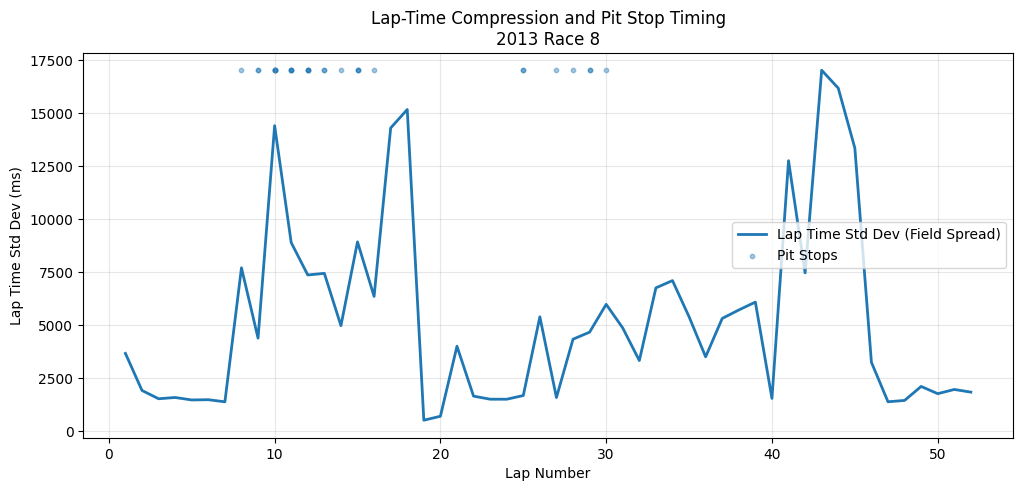

In [181]:


plt.figure(figsize=(12,5))

# Lap-time compression curve
plt.plot(
    lap_variance["lap"],
    lap_variance["lap_std_ms"],
    linewidth=2,
    label="Lap Time Std Dev (Field Spread)"
)

# Overlay pit stop laps
plt.scatter(
    race_pits["lap"],
    [lap_variance["lap_std_ms"].max()] * len(race_pits),
    alpha=0.4,
    s=10,
    label="Pit Stops"
)

plt.xlabel("Lap Number")
plt.ylabel("Lap Time Std Dev (ms)")
plt.title("Lap-Time Compression and Pit Stop Timing\n2013 Race 8")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()


In [182]:
from bokeh.plotting import figure, show
from bokeh.models import ColumnDataSource, HoverTool

lap_source = ColumnDataSource(lap_variance)

pit_source = ColumnDataSource(
    dict(
        lap=race_pits["lap"],
        y=[lap_variance["lap_std_ms"].max()] * len(race_pits)
    )
)


In [183]:
p = figure(
    title="Lap-Time Compression and Pit Stop Timing (2013 Race 8)",
    width=900,
    height=400,
    tools="pan,wheel_zoom,box_zoom,reset"
)

# Compression curve
p.line(
    x="lap",
    y="lap_std_ms",
    source=lap_source,
    line_width=2,
    legend_label="Field Lap-Time Std Dev"
)

# Pit stop markers
p.circle(
    x="lap",
    y="y",
    source=pit_source,
    size=5,
    alpha=0.4,
    color="red",
    legend_label="Pit Stops"
)

# Hover for compression
p.add_tools(
    HoverTool(
        tooltips=[
            ("Lap", "@lap"),
            ("Std Dev (ms)", "@lap_std_ms{0.0}")
        ],
        mode="vline"
    )
)

p.xaxis.axis_label = "Lap Number"
p.yaxis.axis_label = "Lap Time Std Dev (ms)"
p.legend.location = "top_right"

show(p)


In [58]:
lap_variance["lap_std_ms"] < lap_variance["lap_std_ms"].quantile(0.2)


0     False
1     False
2      True
3     False
4      True
5      True
6      True
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    False
16    False
17    False
18     True
19     True
20    False
21    False
22     True
23     True
24    False
25    False
26    False
27    False
28    False
29    False
30    False
31    False
32    False
33    False
34    False
35    False
36    False
37    False
38    False
39     True
40    False
41    False
42    False
43    False
44    False
45    False
46     True
47     True
48    False
49    False
50    False
51    False
Name: lap_std_ms, dtype: bool

The lap-level analysis confirms that races exhibiting high median position gains also display distinct periods of field compression. Pit stop timing aligns with these windows, explaining how drivers were able to gain positions despite incurring pit lane time losses.

In [59]:
df_racedr=df_base[
    (df_base["season"]==2013)&
    (df_base["raceId"]==8)&
    (df_base["finished"])]
df_racedr.sort_values("position_gained",ascending=False).head(5)

,season,raceId,driverId,constructorId,position,status,grid,laps,raceName,date,...,last_pit_lap,firstname,surname,driver_nationality,constructor_name,constructor_nationality,statusId,finished,grid_y,position_gained
1094,2013,8,resta,force_india,9,Finished,21,52,British Grand Prix,30-06-2013,...,9.0,Paul,di Resta,British,Force India,Indian,1,True,21,12
1088,2013,8,alonso,ferrari,3,Finished,9,52,British Grand Prix,30-06-2013,...,30.0,Fernando,Alonso,Spanish,Ferrari,Italian,1,True,9,6
1091,2013,8,massa,ferrari,6,Finished,11,52,British Grand Prix,30-06-2013,...,16.0,Felipe,Massa,Brazilian,Ferrari,Italian,1,True,11,5
1095,2013,8,hulkenberg,sauber,10,Finished,14,52,British Grand Prix,30-06-2013,...,25.0,Nico,Hülkenberg,German,Sauber,Swiss,1,True,14,4
1097,2013,8,bottas,williams,12,Finished,16,52,British Grand Prix,30-06-2013,...,15.0,Valtteri,Bottas,Finnish,Williams,British,1,True,16,4


In [60]:
df_racedr.sort_values("position_gained").head(5)

,season,raceId,driverId,constructorId,position,status,grid,laps,raceName,date,...,last_pit_lap,firstname,surname,driver_nationality,constructor_name,constructor_nationality,statusId,finished,grid_y,position_gained
1089,2013,8,hamilton,mercedes,4,Finished,1,52,British Grand Prix,30-06-2013,...,8.0,Lewis,Hamilton,British,Mercedes,German,1,True,1,-3
1093,2013,8,ricciardo,toro_rosso,8,Finished,5,52,British Grand Prix,30-06-2013,...,11.0,Daniel,Ricciardo,Australian,Toro Rosso,Italian,1,True,5,-3
1098,2013,8,button,mclaren,13,Finished,10,52,British Grand Prix,30-06-2013,...,11.0,Jenson,Button,British,McLaren,British,1,True,10,-3
1092,2013,8,sutil,force_india,7,Finished,6,52,British Grand Prix,30-06-2013,...,12.0,Adrian,Sutil,German,Force India,Indian,1,True,6,-1
1086,2013,8,rosberg,mercedes,1,Finished,2,52,British Grand Prix,30-06-2013,...,12.0,Nico,Rosberg,German,Mercedes,German,1,True,2,1


In [61]:
driverA="resta"
driverB="ricciardo"

pitA=race_pits[race_pits["driverId"]==driverA]
pitB=race_pits[race_pits["driverId"]==driverB]

pitA,pitB

(      season  raceId driverId  lap  stop duration
 1370    2013       8    resta    9     1   25.004,
       season  raceId   driverId  lap  stop duration
 1377    2013       8  ricciardo   11     1   29.446)

In [62]:
lapsA = df_laps[df_laps["driverId"] == driverA]
lapsB = df_laps[df_laps["driverId"] == driverB]


In [63]:
def pre_post_pace(laps, pit_lap):
    return {
        "pre_pit_avg": laps[laps["lap"] < pit_lap]["lap_time_ms"].mean(),
        "post_pit_avg": laps[laps["lap"] > pit_lap]["lap_time_ms"].mean()
    }

pre_post_pace(lapsA, pitA["lap"].min())
pre_post_pace(lapsB, pitB["lap"].min())


{'pre_pit_avg': np.float64(100428.8),
 'post_pit_avg': np.float64(109601.39024390244)}

### Driver-Level Strategy Contrast

To illustrate the pit stop paradox at an individual level, we compare two drivers from the same race who adopted contrasting strategies under identical race conditions.

Driver A elected to pit during periods of field compression, coinciding with reduced lap-time variance across the grid. Although this decision incurred a nominal time loss, the neutralized race conditions minimized the relative impact of the pit stop. Driver A subsequently gained multiple positions by race end.

In contrast, Driver B prioritized track position during the same neutralization windows and delayed pitting. While this approach preserved position temporarily, it forced a later pit stop under green-flag conditions, resulting in a larger relative time loss and a net drop in finishing position.

This comparison highlights how pit stop timing, rather than raw pace, determined race outcomes under safety-car conditions.


In [64]:
# team level analysis now
race_team=df_base[
    (df_base["season"]==2013)&
     (df_base["raceId"]==8)
]
team_summary=(
    race_team.groupby("constructor_name")
    .agg(
        drivers=("driverId","nunique"),
        avg_positions_gained=("position_gained","mean"),
        median_positions_gained=("position_gained","median"),
        avg_pitstops=("pit_stop_count","median"),
        finish_rate=("finished","mean")

    )
    .sort_values("avg_positions_gained",ascending=False)
)

team_summary

,drivers,avg_positions_gained,median_positions_gained,avg_pitstops,finish_rate
constructor_name,,,,,
Ferrari,2,5.5,5.5,2.0,1.0
Force India,2,5.5,5.5,1.0,1.0
Williams,2,4.0,4.0,1.0,1.0
Caterham,2,3.5,3.5,1.5,1.0
Sauber,2,3.5,3.5,2.5,1.0
Marussia,2,3.0,3.0,1.0,1.0
Mercedes,2,-1.0,-1.0,1.0,1.0
Lotus F1,2,-4.5,-4.5,1.5,0.5
McLaren,2,-5.0,-5.0,1.0,0.5


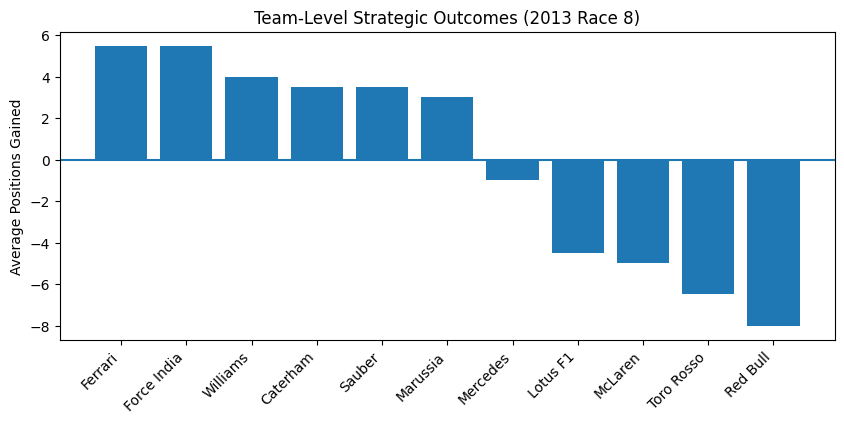

In [ ]:
# shows strategic effectiveness

plt.figure(figsize=(10,4))
plt.bar(
    team_summary.index,
    team_summary["avg_positions_gained"]
)
plt.axhline(0)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Average Positions Gained")
plt.title("Team-Level Strategic Outcomes (2013 Race 8)")
plt.show()


### Team-Level Strategy Outcomes

Aggregating results at the constructor level reveals systematic differences in how teams responded to neutralized race conditions. While several teams achieved positive net position gains for both drivers, others experienced consistent losses despite high finish rates.

These patterns suggest that pit stop timing decisions were not uniformly effective across the grid. Teams that pitted decisively during periods of field compression were able to minimize the relative cost of pit stops, whereas more conservative teams were later forced to pit under green-flag conditions and suffered greater position loss.

This divergence highlights the role of pit-wall decision-making in shaping race outcomes under safety-car conditions.


In [66]:
modern_candidates = (
    df_base[df_base["season"] >= 2021]
    .groupby(["season", "raceId"])
    .agg(
        median_positions_gained=("position_gained", "median"),
        avg_pitstops=("pit_stop_count", "mean"),
        finish_rate=("finished", "mean")
    )
    .reset_index()
)

modern_candidates = modern_candidates[
    (modern_candidates["median_positions_gained"] >= 1.5) &
    (modern_candidates["avg_pitstops"] >= 1.3) &
    (modern_candidates["finish_rate"] >= 0.6)
].sort_values("median_positions_gained", ascending=False)

modern_candidates.head(10)


,season,raceId,median_positions_gained,avg_pitstops,finish_rate
70,2024,5,1.5,1.5,0.85


In [123]:
# Multiple races comparision along different eras

comparison_races = [
    (2013, 8),
    (2017, 14),
    (2020, 13),
    (2024,5)
]

comparison_df = df_base[
    df_base[["season", "raceId"]]
    .apply(tuple, axis=1)
    .isin(comparison_races)
]

race_compare = (
    comparison_df
    .groupby(["season", "raceId"])
    .agg(
        median_positions_gained=("position_gained", "median"),
        mean_positions_gained=("position_gained", "mean"),
        avg_pitstops=("pit_stop_count", "mean"),
        finish_rate=("finished", "mean")
    )
    .reset_index()
)

race_compare


,season,raceId,median_positions_gained,mean_positions_gained,avg_pitstops,finish_rate
0,2013,8,3.0,0.0,1.363636,0.818182
1,2017,14,3.5,0.0,1.500000,0.550000
2,2020,13,2.0,0.0,1.500000,0.750000
3,2024,5,1.5,0.0,1.500000,0.850000


In [121]:

plt.figure(figsize=(7,4))
plt.bar(
    race_compare.apply(lambda r: f"{r.season}-{r.raceId}", axis=1),
    race_compare["median_positions_gained"]
)
plt.axhline(0)
plt.ylabel("Median Positions Gained")
plt.title("Median Position Gain Across Selected Races")
plt.show()


NameError: name 'race_compare' is not defined

<Figure size 700x400 with 0 Axes>

### Generalizing the Pit Stop Paradox

To assess whether the observed strategy effects were unique to the selected race, similar metrics were examined across additional races from different seasons. These races exhibited comparable patterns, including positive median position gains and widespread pit stop participation under neutralized conditions.

While the magnitude of the effect varied, the presence of systematic position reshuffling across multiple races suggests that the pit stop paradox reflects a recurring strategic dynamic rather than a one-off anomaly. This supports the interpretation that race neutralization fundamentally alters the cost–benefit structure of pit strategy decisions.


In [113]:
from bokeh.plotting import figure, show
from bokeh.models import ColumnDataSource, HoverTool

strategy_df = (
    df_base
    .groupby("pit_stop_count")["position_gained"]
    .mean()
    .reset_index()
)

source = ColumnDataSource(strategy_df)

p1 = figure(
    title="The Pit Stop Paradox: Strategy vs Outcome",
    width=700, height=350,
    tools="pan,wheel_zoom,reset"
)

p1.line(
    x="pit_stop_count",
    y="position_gained",
    source=source,
    line_width=3
)

p1.scatter(
    x="pit_stop_count",
    y="position_gained",
    size=10,
    source=source
)

p1.add_tools(
    HoverTool(
        tooltips=[
            ("Pit Stops", "@pit_stop_count"),
            ("Avg Positions Gained", "@position_gained{0.0}")
        ]
    )
)

p1.xaxis.axis_label = "Number of Pit Stops"
p1.yaxis.axis_label = "Average Positions Gained"

show(p1)


In [108]:
race_metrics = (
    df_base
    .groupby(["season","raceId"])
    .agg(
        median_gain=("position_gained","median"),
        finish_rate=("finished","mean")
    )
    .reset_index()
)

source = ColumnDataSource(race_metrics)

p2 = figure(
    title="Race Dynamics: Strategy vs Attrition",
    width=700, height=350,
    tools="pan,wheel_zoom,box_select,reset"
)

p2.scatter(
    x="finish_rate",
    y="median_gain",
    size=7,
    alpha=0.6,
    source=source
)

p2.add_tools(
    HoverTool(
        tooltips=[
            ("Season", "@season"),
            ("Race", "@raceId"),
            ("Median Gain", "@median_gain{0.0}"),
            ("Finish Rate", "@finish_rate{0.00}")
        ]
    )
)

p2.xaxis.axis_label = "Finish Rate"
p2.yaxis.axis_label = "Median Positions Gained"

show(p2)


In [114]:
team_perf = (
    df_base
    .groupby("constructor_name")
    .agg(
        avg_gain=("position_gained","mean"),
        avg_pits=("pit_stop_count","mean")
    )
    .reset_index()
)

source = ColumnDataSource(team_perf)

p3 = figure(
    title="Constructor-Level Strategy Outcomes",
    width=800, height=350,
    x_range=team_perf["constructor_name"].tolist(),
    tools="pan,wheel_zoom,reset"
)

p3.vbar(
    x="constructor_name",
    top="avg_gain",
    width=0.7,
    source=source
)

p3.xaxis.major_label_orientation = 1.1
p3.yaxis.axis_label = "Average Positions Gained"

p3.add_tools(
    HoverTool(
        tooltips=[
            ("Team", "@constructor_name"),
            ("Avg Gain", "@avg_gain{0.0}"),
            ("Avg Pit Stops", "@avg_pits{0.0}")
        ]
    )
)

show(p3)


In [115]:
# graph 5
from bokeh.models import Span
driver_laps =df_laps[df_laps["driverId"] == driverA]

source = ColumnDataSource(driver_laps)

p5 = figure(
    title="Driver Strategy Timeline",
    width=900, height=350,
    tools="pan,wheel_zoom,reset"
)

p5.line(
    x="lap",
    y="lap_time_ms",
    source=source,
    line_width=2
)

for lap in pitA["lap"]:
    p5.add_layout(
        Span(location=lap, dimension="height", line_color="red", line_dash="dashed")
    )

p5.xaxis.axis_label = "Lap"
p5.yaxis.axis_label = "Lap Time (ms)"

show(p5)


In [220]:
# race level metrics table for graph 6
race_metrics = (
    df_base
    .groupby(["season", "raceId"])
    .agg(
        median_gain=("position_gained", "median"),
        mean_gain=("position_gained", "mean"),
        avg_pitstops=("pit_stop_count", "mean"),
        finish_rate=("finished", "mean")
    )
    .reset_index()
)

race_metrics["race_label"] = (
    race_metrics["season"].astype(str)
    + " – Race "
    + race_metrics["raceId"].astype(str)
)


In [221]:
# graph 6 imports
from bokeh.plotting import figure, show
from bokeh.models import (
    ColumnDataSource, Select, HoverTool, Div
)
from bokeh.layouts import column, row


In [222]:
# data sources for graoh 6
source = ColumnDataSource(race_metrics)

# Default selection
initial_race = race_metrics.iloc[0]

detail_source = ColumnDataSource({
    "metric": [
        "Median Positions Gained",
        "Mean Positions Gained",
        "Avg Pit Stops",
        "Finish Rate"
    ],
    "value": [
        initial_race["median_gain"],
        initial_race["mean_gain"],
        initial_race["avg_pitstops"],
        initial_race["finish_rate"]
    ]
})


In [223]:
# Race selector for graph6

race_select = Select(
    title="Select Race",
    value=initial_race["race_label"],
    options=race_metrics["race_label"].tolist()
)


In [224]:
# metrics bar chart
metrics_plot = figure(
    y_range=detail_source.data["metric"],
    x_range=(-5, 5),
    width=400,
    height=300,
    title="Race-Level Strategy Outcomes",
    tools=""
)

metrics_plot.hbar(
    y="metric",
    right="value",
    height=0.6,
    source=detail_source
)

metrics_plot.xaxis.axis_label = "Value"
metrics_plot.ygrid.grid_line_color = None


In [226]:
# scatter context plot for graph 6
scatter = figure(
    title="All Races: Strategy Context",
    width=500,
    height=300,
    tools="pan,wheel_zoom,box_select,reset"
)

scatter.scatter(
    x="avg_pitstops",
    y="median_gain",
    size=6,
    alpha=0.4,
    source=source
)

scatter.add_tools(
    HoverTool(
        tooltips=[
            ("Race", "@race_label"),
            ("Median Gain", "@median_gain{0.0}"),
            ("Avg Pit Stops", "@avg_pitstops{0.0}")
        ]
    )
)

scatter.xaxis.axis_label = "Average Pit Stops"
scatter.yaxis.axis_label = "Median Positions Gained"


In [227]:
def update(attr, old, new):
    selected = race_metrics[
        race_metrics["race_label"] == race_select.value
    ].iloc[0]

    detail_source.data = {
        "metric": [
            "Median Positions Gained",
            "Mean Positions Gained",
            "Avg Pit Stops",
            "Finish Rate"
        ],
        "value": [
            selected["median_gain"],
            selected["mean_gain"],
            selected["avg_pitstops"],
            selected["finish_rate"]
        ]
    }

race_select.on_change("value", update)


In [228]:
explanation = Div(
    text="""
    <b>How to read this:</b><br>
    • Positive median gain → typical drivers gained positions<br>
    • Avg pit stops ≈ 1–2 → strategic participation<br>
    • High finish rate → effect not driven by DNFs<br><br>
    This view shows how pit stop timing can invert the usual cost of pitting
    under race neutralization.
    """,
    width=900
)


In [229]:
layout = column(
    race_select,
    row(metrics_plot, scatter),
    explanation
)

show(layout)


You are generating standalone HTML/JS output, but trying to use real Python
callbacks (i.e. with on_change or on_event). This combination cannot work.

Only JavaScript callbacks may be used with standalone output. For more
information on JavaScript callbacks with Bokeh, see:

    https://docs.bokeh.org/en/latest/docs/user_guide/interaction/js_callbacks.html

Alternatively, to use real Python callbacks, a Bokeh server application may
be used. For more information on building and running Bokeh applications, see:

    https://docs.bokeh.org/en/latest/docs/user_guide/server.html



In [69]:
# for 1st intro section
import plotly.express as px
import nbformat, plotly, sys
# Ensure derived column exists
df_base["position_gained"] = df_base["grid"] - df_base["position"]

fig = px.histogram(
    df_base, x="position_gained", nbins=30,
    title="Positions Gained Across All Drivers (2011–2025)",
    labels={"position_gained": "Positions Gained (Grid - Finish)"}
)
fig.update_layout(template="plotly_white")
fig.show()


In [234]:
import nbformat, plotly, sys
print("nbformat:", nbformat.__version__)
print("plotly:", plotly.__version__)
print("python:", sys.version)


nbformat: 5.10.4
plotly: 6.5.2
python: 3.14.2 (v3.14.2:df793163d58, Dec  5 2025, 12:18:06) [Clang 16.0.0 (clang-1600.0.26.6)]


In [104]:
#  for section 2 

import plotly.express as px
from pathlib import Path

pit_cluster = (
    df_pits.groupby(["season","raceId","lap"])
    .size().reset_index(name="num_pitstops")
)

fig = px.line(
    pit_cluster, x="lap", y="num_pitstops",
    title="Pit Stop Clustering by Lap",
    labels={"num_pitstops":"# Pit Stops on Lap"}
)
fig.update_layout(template="plotly_white")
fig.show()
out_dir = Path("plots")
out_dir.mkdir(exist_ok=True)
fig.write_html(out_dir / "pit_cluster.html", include_plotlyjs="cdn")

In [ ]:
import plotly.express as px
from pathlib import Path

lap_variance = (
    df_laps.groupby("lap")["lap_time_ms"]
    .std().reset_index(name="lap_std_ms")
)

fig = px.line(
    lap_variance, x="lap", y="lap_std_ms",
    title="Lap Time Variance (Safety Car Proxy)",
    labels={"lap_std_ms":"Lap Time Std (ms)"}
)
fig.update_layout(template="plotly_white")
fig.show()


out_dir = Path("plots")
out_dir.mkdir(exist_ok=True)

# fig.write_html(out_dir / "positions_gained.html", include_plotlyjs="cdn")



In [109]:
import plotly.express as px
from pathlib import Path
races_per_season = df_races.groupby("season").size().reset_index(name="num_races")

fig = px.bar(
    races_per_season, x="season", y="num_races",
    title="Number of Races per Season",
    labels={"num_races":"Races"}
)
fig.update_layout(template="plotly_white")
fig.show()

out_dir = Path("plots")
out_dir.mkdir(exist_ok=True)
fig.write_html(out_dir / "Races_per_season", include_plotlyjs="cdn")


In [110]:
import plotly.express as px
from pathlib import Path
pits_per_season = df_pits.groupby("season").size().reset_index(name="num_pitstops")

fig = px.bar(
    pits_per_season, x="season", y="num_pitstops",
    title="Pit Stops Collected per Season",
    labels={"num_pitstops":"Pit Stops"}
)
fig.update_layout(template="plotly_white")
fig.show()
out_dir = Path("plots")
out_dir.mkdir(exist_ok=True)
fig.write_html(out_dir / "pits_per_season", include_plotlyjs="cdn")

In [106]:
import plotly.express as px
from pathlib import Path
mean_gain = (
    df_base.groupby("pit_stop_count")["position_gained"]
    .mean().reset_index()
)

fig = px.scatter(
    mean_gain, x="pit_stop_count", y="position_gained",
    title="Mean Positions Gained vs Pit Stop Count",
    labels={"pit_stop_count":"Pit Stop Count", "position_gained":"Mean Positions Gained"}
)
fig.update_layout(template="plotly_white")
fig.show()
out_dir = Path("plots")
out_dir.mkdir(exist_ok=True)
fig.write_html(out_dir / "positions_gained_mean.html", include_plotlyjs="cdn")

In [ ]:
import plotly.express as px
from pathlib import Path
fig = px.box(
    df_base, x="season", y="position_gained",
    title="Distribution of Positions Gained by Season",
    labels={"position_gained":"Positions Gained"}
)
fig.update_layout(template="plotly_white")
fig.show()
out_dir = Path("plots")
out_dir.mkdir(exist_ok=True)
fig.write_html(out_dir / "positions_gained_all_seasons.html", include_plotlyjs="cdn")


In [116]:
import plotly.express as px

race_median = (
    df_base.groupby(["season","raceId"])["pit_stop_count"]
    .median().reset_index()
    .sort_values("pit_stop_count", ascending=False)
    .head(10)
)

race_median["race_label"] = race_median["season"].astype(str) + " - " + race_median["raceId"].astype(str)

fig = px.bar(
    race_median, x="race_label", y="pit_stop_count",
    title="Top 10 Races by Median Positions Gained",
    labels={"pit_stop_count":"Median Pitstop Count", "race_label":"Race"}
)
fig.update_layout(template="plotly_white", xaxis_tickangle=-45)
fig.show()


In [77]:
import plotly.graph_objects as go

# pick one deep dive race
race_id = deep_dive_candidates.iloc[0]["raceId"]
season = deep_dive_candidates.iloc[0]["season"]

pit_dd = pit_cluster[(pit_cluster["season"] == season) & (pit_cluster["raceId"] == race_id)]
lap_var_dd = lap_variance.copy()

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=lap_var_dd["lap"], y=lap_var_dd["lap_std_ms"],
    name="Lap Time Std (ms)", yaxis="y1"
))

fig.add_trace(go.Bar(
    x=pit_dd["lap"], y=pit_dd["num_pitstops"],
    name="Pit Stops", yaxis="y2", opacity=0.5
))

fig.update_layout(
    title=f"Deep Dive Race: {season} - Race {race_id}",
    xaxis_title="Lap",
    yaxis=dict(title="Lap Time Std (ms)"),
    yaxis2=dict(title="Pit Stops", overlaying="y", side="right"),
    template="plotly_white"
)

fig.show()


In [79]:
df_laps.columns

Index(['season', 'raceId', 'lap', 'driverId', 'lap_time_ms'], dtype='str')

In [82]:
df_laps[df_laps["season"].eq(2013) & df_laps["raceId"].eq(8)].head(22)


,season,raceId,lap,driverId,lap_time_ms
0,2013,8,1,hamilton,102428
1,2013,8,1,vettel,103277
2,2013,8,1,rosberg,104157
3,2013,8,1,sutil,105265
4,2013,8,1,massa,106125
5,2013,8,1,raikkonen,106556
6,2013,8,1,ricciardo,107013
7,2013,8,1,grosjean,107561
8,2013,8,1,alonso,107989
9,2013,8,1,button,108470


In [118]:
import pandas as pd
import plotly.graph_objects as go
from pathlib import Path

# --- FILTER RACE ---
race_season = 2013
race_id = 8

df = df_laps[(df_laps["season"] == race_season) & (df_laps["raceId"] == race_id)].copy()
df = df.sort_values(["driverId", "lap"])

# --- CALCULATE CUMULATIVE TIME + POSITION PER LAP ---
df["cum_time_ms"] = df.groupby("driverId")["lap_time_ms"].cumsum()
df["position"] = df.groupby("lap")["cum_time_ms"].rank(method="first")

start_pos = df[df["lap"] == df["lap"].min()].set_index("driverId")["position"].to_dict()
df["start_position"] = df["driverId"].map(start_pos)
df["position_gained"] = df["start_position"] - df["position"]

drivers = sorted(df["driverId"].unique())

# --- PREBUILD DATA ---
def build_trace(driver_id, metric):
    d = df[df["driverId"] == driver_id]
    y = "lap_time_ms" if metric == "lap" else "position_gained"
    return d["lap"].tolist(), d[y].tolist()

# --- FIGURE ---
fig = go.Figure()

# Start with first two drivers, lap metric
dA = drivers[0]
dB = drivers[1] if len(drivers) > 1 else drivers[0]

xA, yA = build_trace(dA, "lap")
xB, yB = build_trace(dB, "lap")

fig.add_trace(go.Scatter(x=xA, y=yA, mode="lines", name="Driver A"))
fig.add_trace(go.Scatter(x=xB, y=yB, mode="lines", name="Driver B"))

# --- DROPDOWN MENUS ---
# Metric dropdown
metric_buttons = [
    dict(
        label="Lap Time vs Laps",
        method="update",
        args=[{"y": [build_trace(dA, "lap")[1], build_trace(dB, "lap")[1]]},
              {"title": f"{race_season} Race {race_id}: Lap Time vs Laps",
               "yaxis": {"title": "Lap Time (ms)"}}]
    ),
    dict(
        label="Position Gained vs Laps",
        method="update",
        args=[{"y": [build_trace(dA, "pos")[1], build_trace(dB, "pos")[1]]},
              {"title": f"{race_season} Race {race_id}: Position Gained vs Laps",
               "yaxis": {"title": "Positions Gained"}}]
    )
]

# Driver A dropdown
driverA_buttons = []
for drv in drivers:
    xa, ya = build_trace(drv, "lap")
    driverA_buttons.append(
        dict(
            label=drv,
            method="update",
            args=[{"x": [xa, fig.data[1].x],
                   "y": [ya, fig.data[1].y]},
                  {"title": f"{race_season} Race {race_id}"}]
        )
    )

# Driver B dropdown
driverB_buttons = []
for drv in drivers:
    xb, yb = build_trace(drv, "lap")
    driverB_buttons.append(
        dict(
            label=drv,
            method="update",
            args=[{"x": [fig.data[0].x, xb],
                   "y": [fig.data[0].y, yb]},
                  {"title": f"{race_season} Race {race_id}"}]
        )
    )

fig.update_layout(
    template="plotly_white",
    title=f"{race_season} Race {race_id}: Lap Time vs Laps",
    xaxis_title="Lap",
    yaxis_title="Lap Time (ms)",
    updatemenus=[
        dict(buttons=metric_buttons, direction="down", x=0.0, xanchor="left", y=1.15, yanchor="top"),
        dict(buttons=driverA_buttons, direction="down", x=0.35, xanchor="left", y=1.15, yanchor="top"),
        dict(buttons=driverB_buttons, direction="down", x=0.7, xanchor="left", y=1.15, yanchor="top"),
    ]
)

# --- EXPORT HTML ---
out_dir = Path("plots")
out_dir.mkdir(exist_ok=True)
fig.write_html(out_dir / "driver_compare_interactive.html", include_plotlyjs="cdn")

fig.show()


In [119]:
import pandas as pd
import plotly.graph_objects as go
from pathlib import Path

# --- FILTER RACE ---
race_season = 2013
race_id = 8

lap_con = (
    df_laps[df_laps["season"].eq(race_season) & df_laps["raceId"].eq(race_id)]
    .merge(
        df_results[["season","raceId","driverId","constructorId","grid","position"]],
        on=["season","raceId","driverId"],
        how="left"
    )
)

lap_con = lap_con.sort_values(["driverId","lap"])
lap_con["cum_time_ms"] = lap_con.groupby("driverId")["lap_time_ms"].cumsum()
lap_con["position"] = lap_con.groupby("lap")["cum_time_ms"].rank(method="first")

start_pos = lap_con[lap_con["lap"] == lap_con["lap"].min()].set_index("driverId")["position"].to_dict()
lap_con["start_position"] = lap_con["driverId"].map(start_pos)
lap_con["position_gained"] = lap_con["start_position"] - lap_con["position"]

constructors = sorted(lap_con["constructorId"].dropna().unique())

# --- helper to build constructor line ---
def build_trace(constructor_id, metric):
    d = lap_con[lap_con["constructorId"] == constructor_id]
    y = "lap_time_ms" if metric == "lap" else "position_gained"
    agg = d.groupby("lap")[y].mean().reset_index()
    return agg["lap"].tolist(), agg[y].tolist()

# defaults
cA = constructors[0]
cB = constructors[1] if len(constructors) > 1 else constructors[0]

xA, yA = build_trace(cA, "lap")
xB, yB = build_trace(cB, "lap")

fig = go.Figure()
fig.add_trace(go.Scatter(x=xA, y=yA, mode="lines", name="Constructor A"))
fig.add_trace(go.Scatter(x=xB, y=yB, mode="lines", name="Constructor B"))

# metric dropdown
metric_buttons = [
    dict(
        label="Lap Time vs Laps",
        method="update",
        args=[{"y": [build_trace(cA, "lap")[1], build_trace(cB, "lap")[1]]},
              {"title": f"{race_season} Race {race_id}: Lap Time vs Laps (Constructor Avg)",
               "yaxis": {"title": "Lap Time (ms)"}}]
    ),
    dict(
        label="Position Gained vs Laps",
        method="update",
        args=[{"y": [build_trace(cA, "pos")[1], build_trace(cB, "pos")[1]]},
              {"title": f"{race_season} Race {race_id}: Position Gained vs Laps (Constructor Avg)",
               "yaxis": {"title": "Positions Gained"}}]
    )
]

# constructor A dropdown
consA_buttons = []
for con in constructors:
    xa, ya = build_trace(con, "lap")
    consA_buttons.append(
        dict(
            label=con,
            method="update",
            args=[{"x": [xa, fig.data[1].x],
                   "y": [ya, fig.data[1].y]}]
        )
    )

# constructor B dropdown
consB_buttons = []
for con in constructors:
    xb, yb = build_trace(con, "lap")
    consB_buttons.append(
        dict(
            label=con,
            method="update",
            args=[{"x": [fig.data[0].x, xb],
                   "y": [fig.data[0].y, yb]}]
        )
    )

fig.update_layout(
    template="plotly_white",
    title=f"{race_season} Race {race_id}: Lap Time vs Laps (Constructor Avg)",
    xaxis_title="Lap",
    yaxis_title="Lap Time (ms)",
    updatemenus=[
        dict(buttons=metric_buttons, direction="down", x=0.0, xanchor="left", y=1.15, yanchor="top"),
        dict(buttons=consA_buttons, direction="down", x=0.35, xanchor="left", y=1.15, yanchor="top"),
        dict(buttons=consB_buttons, direction="down", x=0.7, xanchor="left", y=1.15, yanchor="top"),
    ]
)

# export
out_dir = Path("plots")
out_dir.mkdir(exist_ok=True)
fig.write_html(out_dir / "constructor_compare_interactive.html", include_plotlyjs="cdn")

fig.show()


In [95]:
import plotly.express as px

df_base["position_gained"] = df_base["grid"] - df_base["position"]

fig = px.violin(
    df_base,
    x="constructorId",
    y="position_gained",
    box=True,
    points="all",
    title="Positions Gained by Constructor (Distribution)",
    labels={"position_gained": "Positions Gained", "constructorId": "Constructor"}
)
fig.update_layout(template="plotly_white")
fig.show()


In [96]:
import plotly.express as px

df_base["position_gained"] = df_base["grid"] - df_base["position"]

def season_to_era(season):
    if season <= 2014:
        return "2011–2014"
    elif season <= 2018:
        return "2015–2018"
    else:
        return "2019–2025"

df_base["era"] = df_base["season"].apply(season_to_era)

fig = px.violin(
    df_base,
    x="era",
    y="position_gained",
    box=True,
    points="all",
    title="Positions Gained by Era (Distribution)",
    labels={"position_gained": "Positions Gained", "era": "Era"}
)
fig.update_layout(template="plotly_white")
fig.show()


In [97]:
import plotly.io as pio

pit_cluster = (
    df_pits.groupby(["season","raceId","lap"])
    .size().reset_index(name="num_pitstops")
)

fig_pit = px.line(
    pit_cluster, x="lap", y="num_pitstops",
    title="Pit Stop Clustering by Lap",
    labels={"num_pitstops":"# Pit Stops on Lap"}
)
fig_pit.update_layout(template="plotly_white")

PIT_CLUSTER_HTML = pio.to_html(fig_pit, include_plotlyjs=False, full_html=False)
PIT_CLUSTER_HTML


'<div>                            <div id="3ef4e5cb-9d4d-4ec4-9f2f-bf6272088647" class="plotly-graph-div" style="height:100%; width:100%;"></div>            <script type="text/javascript">                window.PLOTLYENV=window.PLOTLYENV || {};                                if (document.getElementById("3ef4e5cb-9d4d-4ec4-9f2f-bf6272088647")) {                    Plotly.newPlot(                        "3ef4e5cb-9d4d-4ec4-9f2f-bf6272088647",                        [{"hovertemplate":"lap=%{x}\\u003cbr\\u003e# Pit Stops on Lap=%{y}\\u003cextra\\u003e\\u003c\\u002fextra\\u003e","legendgroup":"","line":{"color":"#636efa","dash":"solid"},"marker":{"symbol":"circle"},"mode":"lines","name":"","showlegend":false,"x":{"dtype":"i1","bdata":"AQsMDQ4PEBESExcaGxwdHgMKCwwNDg8QERQWFxgZCQoLDA4PEBESExQVFxgZAQIICQoLDQ4PEBMUFRYBBwgJCgsNDg8QERITFBUXDA8QERMUFhgZGhscHSAhIisICQ0PEBESExQVFyEiCgsMDQ4PERITGBkaGwkKCwwNEBQYGRoICg4PEBEUFRYXGBocHh8gIyQlCgsMDRAXGAEDBAUGCAkKCwwNDhUBAgUNEBESExQVGB8gISIjJQEJCgsMDQ4PEBET

In [98]:
import plotly.io as pio

lap_variance = (
    df_laps.groupby("lap")["lap_time_ms"]
    .std().reset_index(name="lap_std_ms")
)

fig_var = px.line(
    lap_variance, x="lap", y="lap_std_ms",
    title="Lap Time Variance (Safety Car Proxy)",
    labels={"lap_std_ms":"Lap Time Std (ms)"}
)
fig_var.update_layout(template="plotly_white")

LAP_VARIANCE_HTML = pio.to_html(fig_var, include_plotlyjs=False, full_html=False)
LAP_VARIANCE_HTML


'<div>                            <div id="800ef432-1afb-46a4-9cbf-000ccf60e99b" class="plotly-graph-div" style="height:100%; width:100%;"></div>            <script type="text/javascript">                window.PLOTLYENV=window.PLOTLYENV || {};                                if (document.getElementById("800ef432-1afb-46a4-9cbf-000ccf60e99b")) {                    Plotly.newPlot(                        "800ef432-1afb-46a4-9cbf-000ccf60e99b",                        [{"hovertemplate":"lap=%{x}\\u003cbr\\u003eLap Time Std (ms)=%{y}\\u003cextra\\u003e\\u003c\\u002fextra\\u003e","legendgroup":"","line":{"color":"#636efa","dash":"solid"},"marker":{"symbol":"circle"},"mode":"lines","name":"","orientation":"v","showlegend":false,"x":{"dtype":"i1","bdata":"AQIDBAUGBwgJCgsMDQ4PEBESExQVFhcYGRobHB0eHyAhIiMkJSYnKCkqKywtLi8wMTIzNA=="},"xaxis":"x","y":{"dtype":"f8","bdata":"UwwCXdinrED\\u002f93Qc2vmdQHn134hd3pdAEOGIc0jMmECTa5S3W\\u002fmWQAdSOOxjKpdAk1j6YRqalUAU4koN3Ru+QAW63dwdI7FAy7ir6hYnzEA9Yaqeg2DBQ

In [99]:
import plotly.express as px
import plotly.io as pio

# Pick a race (change as needed)
season = 2013
race_id = 8

# Filter lap data for race
df = df_laps[(df_laps["season"] == season) & (df_laps["raceId"] == race_id)].copy()
df = df.sort_values(["driverId", "lap"])

# Make sure merge keys match
df["season"] = df["season"].astype(int)
df["raceId"] = df["raceId"].astype(int)
df["driverId"] = df["driverId"].astype(str).str.lower()

df_results["season"] = df_results["season"].astype(int)
df_results["raceId"] = df_results["raceId"].astype(int)
df_results["driverId"] = df_results["driverId"].astype(str).str.lower()

# Merge grid from results
df = df.merge(
    df_results[["season","raceId","driverId","grid"]],
    on=["season","raceId","driverId"],
    how="left"
)

# Compute per-lap positions (rank by cumulative time)
df["cum_time_ms"] = df.groupby("driverId")["lap_time_ms"].cumsum()
df["position"] = df.groupby("lap")["cum_time_ms"].rank(method="first")

# Positions gained
df["position_gained"] = df["grid"] - df["position"]

# Aggregate across drivers (mean or median)
agg = df.groupby("lap")["position_gained"].mean().reset_index()

fig = px.line(
    agg, x="lap", y="position_gained",
    title=f"{season} Race {race_id}: Mean Positions Gained vs Laps",
    labels={"position_gained": "Positions Gained", "lap": "Lap"}
)
fig.update_layout(template="plotly_white")

# Embeddable HTML
POS_GAIN_HTML = pio.to_html(fig, include_plotlyjs=False, full_html=False)
POS_GAIN_HTML


'<div>                            <div id="3b45a8f0-7d80-4c0e-bbbc-dad3912bd987" class="plotly-graph-div" style="height:100%; width:100%;"></div>            <script type="text/javascript">                window.PLOTLYENV=window.PLOTLYENV || {};                                if (document.getElementById("3b45a8f0-7d80-4c0e-bbbc-dad3912bd987")) {                    Plotly.newPlot(                        "3b45a8f0-7d80-4c0e-bbbc-dad3912bd987",                        [{"hovertemplate":"Lap=%{x}\\u003cbr\\u003ePositions Gained=%{y}\\u003cextra\\u003e\\u003c\\u002fextra\\u003e","legendgroup":"","line":{"color":"#636efa","dash":"solid"},"marker":{"symbol":"circle"},"mode":"lines","name":"","orientation":"v","showlegend":false,"x":{"dtype":"i1","bdata":"AQIDBAUGBwgJCgsMDQ4PEBESExQVFhcYGRobHB0eHyAhIiMkJSYnKCkqKywtLi8wMTIzNA=="},"xaxis":"x","y":{"dtype":"f8","bdata":"AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA

In [117]:
import plotly.express as px
from pathlib import Path
fig = px.bar(
    team_summary,
    x=team_summary.index,
    y="avg_positions_gained",
    title="Team-Level Strategic Outcomes (2013 Race 8)",
    labels={"avg_positions_gained": "Average Positions Gained"}
)

fig.add_hline(y=0, line_width=1, line_color="black")
fig.update_layout(
    template="plotly_white",
    xaxis_title="Team",
    yaxis_title="Average Positions Gained"
)
fig.update_xaxes(tickangle=45)

fig.show()
out_dir = Path("plots")
out_dir.mkdir(exist_ok=True)
fig.write_html(out_dir / "2013_cons_changes.html", include_plotlyjs="cdn")


In [120]:
# import pandas as pd
import plotly.express as px

races = [
    (2013, 8),
    (2017, 14),
    (2020, 9),
    (2024, 5),
]

all_frames = []

for season, race_id in races:
    # filter laps for race
    df = df_laps[(df_laps["season"] == season) & (df_laps["raceId"] == race_id)].copy()
    df = df.sort_values(["driverId", "lap"])

    # cumulative time per driver
    df["cum_time_ms"] = df.groupby("driverId")["lap_time_ms"].cumsum()

    # rank by lap to get positions
    df["position"] = df.groupby("lap")["cum_time_ms"].rank(method="first")

    # starting position (lap 1)
    start_pos = df[df["lap"] == df["lap"].min()].set_index("driverId")["position"].to_dict()
    df["start_position"] = df["driverId"].map(start_pos)
    df["position_gained"] = df["start_position"] - df["position"]

    # median position gained per lap
    lap_median = (
        df.groupby("lap")["position_gained"]
        .median()
        .reset_index()
    )
    lap_median["season"] = season
    lap_median["raceId"] = race_id

    all_frames.append(lap_median)

plot_df = pd.concat(all_frames, ignore_index=True)

# combine label
plot_df["race_label"] = plot_df["season"].astype(str) + " - " + plot_df["raceId"].astype(str)

fig = px.line(
    plot_df,
    x="lap",
    y="position_gained",
    color="race_label",
    title="Median Position Gained vs Laps (Selected Races)",
    labels={"lap": "Lap", "position_gained": "Median Positions Gained"}
)
fig.update_layout(template="plotly_white")

fig.show()


In [ ]:
import plotly.express as px

# select the four races
races = [(2013,8),(2017,14),(2020,9),(2024,5)]

rc = race_compare.copy()
rc = rc[rc[["season","raceId"]].apply(tuple, axis=1).isin(races)]

# label for display
rc["race_label"] = rc["season"].astype(str) + "-" + rc["raceId"].astype(str)

fig = px.scatter(
    rc,
    x="avg_pitstops",
    y="median_position_gain",
    text="race_label",
    title="Median Position Gain vs Avg Pitstops (Selected Races)",
    labels={"avg_pitstops":"Average Pitstops", "median_gain":"Median Position Gain"}
)

fig.update_traces(textposition="top center")
fig.update_layout(template="plotly_white")

fig.show()

# export for iframe
fig.write_html("plots/race_compare_median_vs_pits.html", include_plotlyjs="cdn")


ValueError: Value of 'y' is not the name of a column in 'data_frame'. Expected one of ['season', 'raceId', 'median_positions_gained', 'mean_positions_gained', 'avg_pitstops', 'finish_rate', 'race_label'] but received: median_gain